# BUCSS 2026
## AI Session Hands-On Part 1: Data Insights and Pre-processing

In this notebook you will:
- Load observational data from weather station networks of different cities
- Visualize observations
- Prepare data sets for training (next part, different notebook)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cmcrameri.cm as cmc

#These are internal
from scripts.dataprep import load_data
from scripts.plotting import obs_map, week_plot

First, let's decide which city you want to extract your data from:

In [3]:
data = load_data("dortmund") #options are "bern", "dortmund", "freiburg", "ghent"

# print(data) #you can check out how we load the data in ../scripts/dataprep.py 
# this returns a basic dataframe with a station id, coordinates, datetime of the measurement and the
# measured value in °C
 


reading raw data


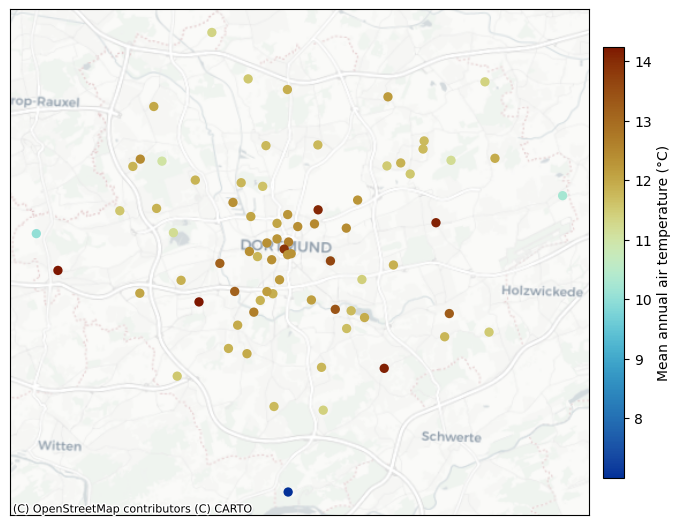

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [4]:
# We can do a basic map to display where the measurements took place, with circles colored by their average temperature

# we take the mean observed temperature for each station and in so doing collapse the datafame
# to one row per station
stn = (data.groupby("station_id")
            .agg(longitude=("longitude", "first"),
                    latitude=("latitude", "first"),
                    tmean=("air_temperature", "mean"))
            .reset_index())

obs_map(stn, value_col = "tmean")

Let's see how a typical diurnal cycle would look for the hottest and coldest stations, in the hottest week of summer.

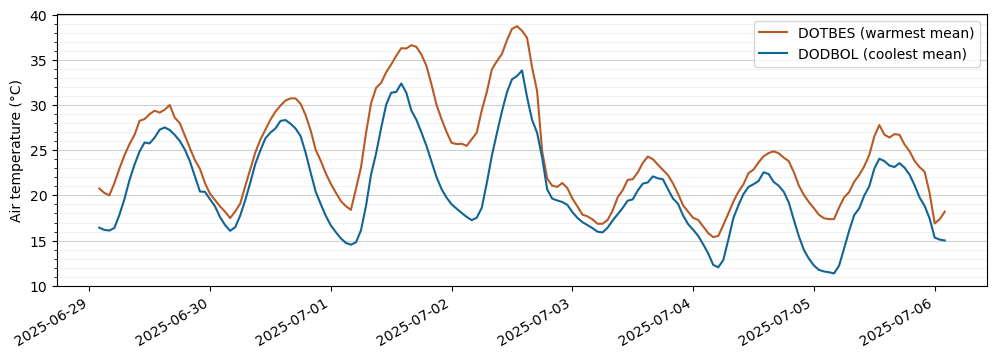

hottest_time: 2025-07-02 14:00:00+00:00
window rows: 12242  in_window rows: 12242
counts.max(): 169  threshold: 84.5
n stations clearing 70%: 72
station_id
DOBBHS    169
DOBBRS    169
DOBCLA    169
DOBDHS    169
DOBDKP    169
DOBDOU    169
DOBGAS    169
DOBHAN    169
DOBHAP    169
DOBHBF    169
Name: datetime_utc, dtype: int64
hot_id: DOTBES  cold_id: DODBOL
hot_week rows: 169  cold_week rows: 169
169 non-NaN of 169
count    169.000000
mean      24.463802
std        5.740173
min       15.380997
25%       20.065612
50%       23.602177
75%       28.273125
max       38.768749
Name: air_temperature, dtype: float64
count    169.000000
mean      20.787917
std        5.126118
min       11.357143
25%       17.041667
50%       19.980000
75%       24.071429
max       33.858333
Name: air_temperature, dtype: float64


In [7]:
# find the time with the absolute hottest temperature measured
hottest_time = data.loc[data["air_temperature"].idxmax(), "datetime_utc"]

# we set up a time window that is a week long, centered around the hottest time
half = pd.Timedelta(days=3.5)
lo, hi = hottest_time - half, hottest_time + half
window = data["datetime_utc"].between(lo, hi)

# filter to stations that have data during this hot week
in_window = data[window]

# observation count per station within the window
counts = in_window.groupby("station_id")["datetime_utc"].count()

# keep stations with >= 70% of the best-covered station's count
threshold = 0.5 * counts.max()
present_ids = counts[counts >= threshold].index

# mean temp per WELL-COVERED station during the window
stn = (in_window[in_window["station_id"].isin(present_ids)]
           .groupby("station_id")["air_temperature"].mean()
           .rename("tmean").reset_index())

hot_id  = stn.loc[stn["tmean"].idxmax(), "station_id"]
cold_id = stn.loc[stn["tmean"].idxmin(), "station_id"]

hot_week  = data[(data["station_id"] == hot_id)  & window].sort_values("datetime_utc")
cold_week = data[(data["station_id"] == cold_id) & window].sort_values("datetime_utc")

week_plot(hot_week, cold_week, hot_id, cold_id)

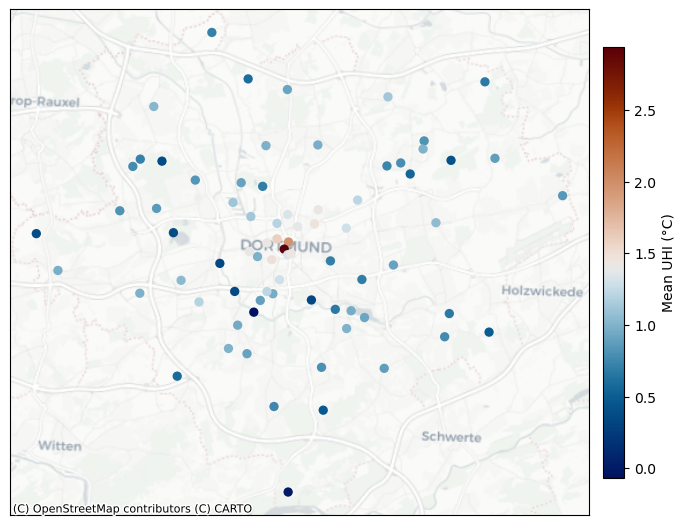

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [4]:

stn = (data.groupby("station_id")
            .agg(longitude=("longitude", "first"),
                    latitude=("latitude", "first"),
                    tmean=("air_temperature", "mean"))
            .reset_index())

rural_id = stn.loc[stn["tmean"].idxmin(), "station_id"]


rural = (data.loc[data["station_id"] == rural_id, ["datetime_utc", "air_temperature"]]
             .rename(columns={"air_temperature": "t_rural"}))

m = data.merge(rural, on="datetime_utc", how="inner")

m["uhi"] = m["air_temperature"] - m["t_rural"]

uhi = m.groupby("station_id")["uhi"].mean().reset_index(name="uhi_mean")

uhi = uhi.merge(stn[["station_id", "longitude", "latitude"]], on="station_id")

obs_map(uhi, value_col = "uhi_mean")

Why are the Bern values so high ? Let's take a closer look at what time period they cover:

In [16]:
print(data["datetime_utc"].min())
print(data["datetime_utc"].max())

2022-04-05 00:00:00+00:00
2023-12-31 23:00:00+00:00


Maybe that's not enough, let's make a histogram that displays the number of observations per month:

/scratch/local/11609196/ipykernel_535790/4036120785.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  months = data["datetime_utc"].dt.to_period("M")


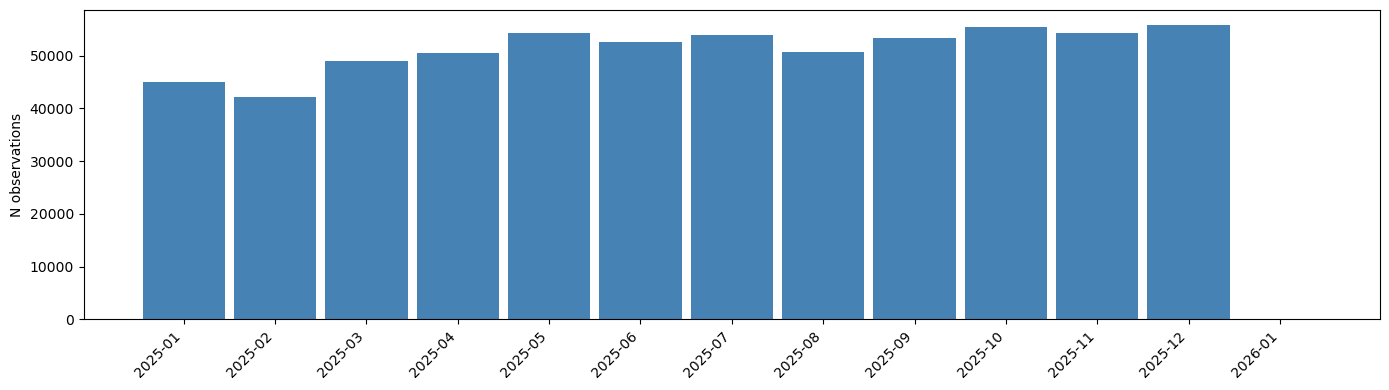

(<Figure size 1400x400 with 1 Axes>, <Axes: ylabel='N observations'>)

In [8]:
def obs_per_month(data: pd.DataFrame):
    #group the data per month
    months = data["datetime_utc"].dt.to_period("M")

    # count observations per calendar month
    counts = months.value_counts().sort_index()

    # build the FULL month range and reindex -> missing months become 0
    full = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
    counts = counts.reindex(full, fill_value=0)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(counts.index.astype(str), counts.values, width=0.9, color="steelblue")
    ax.set_ylabel("N observations")

    # thin the x labels so they don't collide
    step = max(1, len(counts) // 24)
    ax.set_xticks(range(0, len(counts), step))
    ax.set_xticklabels([str(counts.index[i]) for i in range(0, len(counts), step)],
                       rotation=45, ha="right")
    fig.tight_layout()
    plt.show()
    return fig, ax

obs_per_month(data)

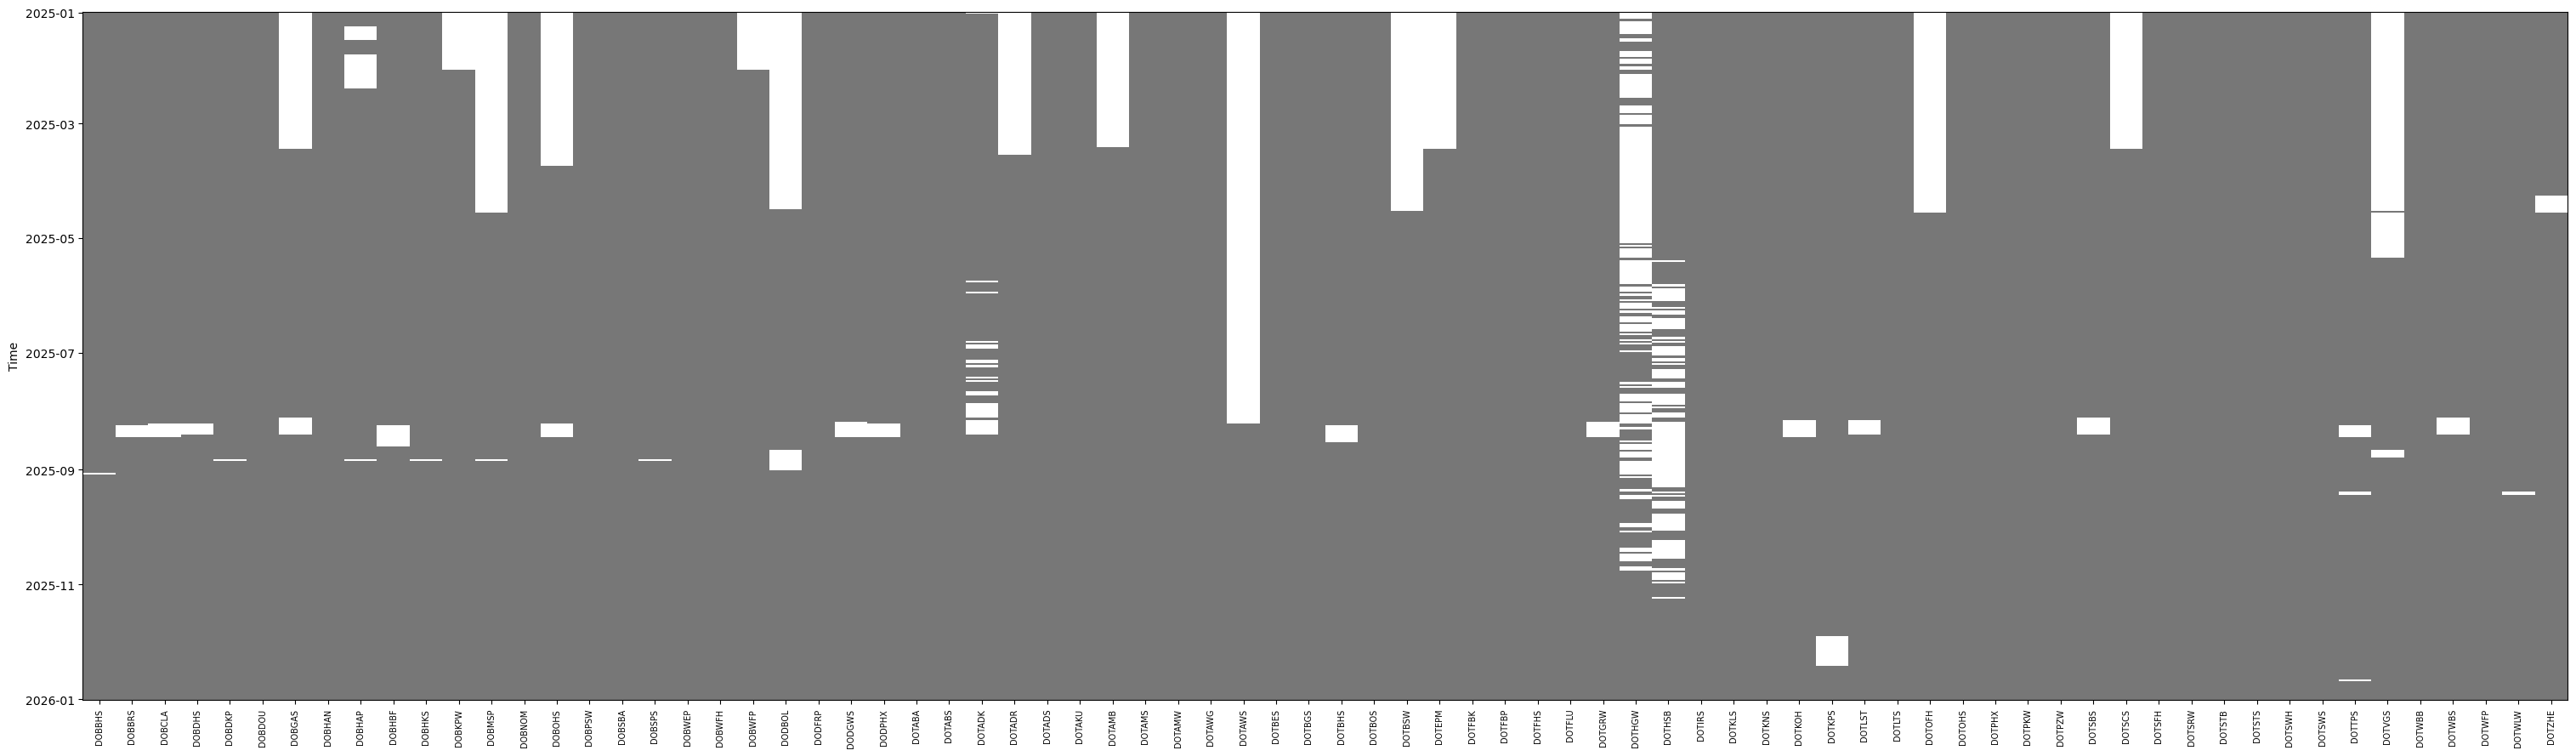

(<Figure size 3040x900 with 1 Axes>, <Axes: ylabel='Time'>)

In [9]:
def availability(data: pd.DataFrame, freq="D"):
    # sort stations by ID instead of date
    stations = sorted(data["station_id"].unique())

    # get the time axis on which observations are given
    t0 = data["datetime_utc"].min().floor(freq)
    t1 = data["datetime_utc"].max().floor(freq)

    #slots that are available to be plotted according to the desired frequency (daily by default)
    slots = pd.date_range(t0, t1, freq=freq, tz="UTC")

    fig, ax = plt.subplots(figsize=(max(8, 0.4 * len(stations)), 9))

    #we initialize an empty grid to fill the data availability with
    grid = np.full((len(slots), len(stations)), np.nan)
    # j = counter, sid = station id
    for j, sid in enumerate(stations):
        # which slots does this station have any obs in?
        s = data.loc[data["station_id"] == sid, "datetime_utc"]
        # bin this station's obs onto the SAME slots via floor, then mark hits
        binned = s.dt.floor(freq)
        
        # this will bin any number of hourly observations to the same day
        hit = pd.Series(True, index=binned).groupby(level=0).any()

        # we re-align this station's observational span to the span of the entire series and do not fill empty values
        hit = hit.reindex(slots, fill_value=False)

        # fill the grid with 1 when we have observations
        grid[hit.values, j] = 1.0 

    one_gray = ListedColormap([cmc.grayC(0.5)])    
    # use pcolormesh method for gridded data
    ax.pcolormesh(np.arange(len(stations)), slots, grid,
                  cmap=one_gray, vmin=0, vmax=1, shading="nearest")

    ax.set_xticks(np.arange(len(stations)))          # 0,1,2,... = cell centers
    ax.set_xticklabels(stations, rotation=90, fontsize=7)
    ax.set_ylabel("Time")
    ax.invert_yaxis()          # earliest at top, latest at bottom
    fig.tight_layout()
    plt.show()
    return fig, ax

availability(data)

# Raster data
Okay now that we have clean data and we know what it looks like, we can start processing the predictors we might need.